In [40]:
import pandas as pd
import numpy  as np
from pathlib import Path
import matplotlib.pyplot as plt
import pypsa
import yaml

In [41]:
with open(
    Path.cwd().parent / 'config.basicrun.yaml'
) as f:
    config = yaml.safe_load(f)
model_countries = config['countries']

In [42]:
with open(
    Path.cwd().parent / 'config.basicrun.yaml'
) as f:
    config = yaml.safe_load(f)
tech_colors = config['plotting']['tech_colors']

In [43]:
countries = [
    'DE', 'FR', 'GB', 'IT', 'ES', 'PL', 'SE', 'NO', 'NL', 'FI', 'RO', 'GR',
    'PT', 'CZ', 'BE', 'AT', 'BG', 'DK', 'HU', 'IE'# , 'HR', 'LT', 'LV', 'EE'
]

In [44]:
hold = pd.read_csv(
    Path.cwd().parent / 'data' / 'ELEC-C_20260226-103428.csv',
    encoding='latin-1'
)

In [45]:
hold.index.unique(0)[-20:]

Index(['Tunisia', 'Turkmenistan', 'Turks and Caicos Islands', 'Tuvalu',
       'Türkiye', 'Uganda', 'Ukraine', 'United Arab Emirates (the)',
       'United Kingdom of Great Britain and Northern Ireland (the)',
       'United Republic of Tanzania (the)', 'United States Virgin Islands',
       'United States of America (the)', 'Uruguay', 'Uzbekistan', 'Vanuatu',
       'Venezuela (Bolivarian Republic of)', 'Viet Nam', 'Yemen', 'Zambia',
       'Zimbabwe'],
      dtype='object')

In [46]:
df = pd.read_csv(
    Path.cwd().parent / 'data' / 'ELEC-C_20260226-103428.csv',
    encoding='latin-1'
)

In [47]:
# Rename UK to GB in level 0 (country codes)
level_0_values = df.index.get_level_values(0)
renamed_values = level_0_values.map(lambda x: 'United Kingdom' if x == 'United Kingdom of Great Britain and Northern Ireland (the)' else x)

# Rebuild the index with renamed values
new_index_arrays = [renamed_values]
for i in range(1, df.index.nlevels):
    level_values = df.index.get_level_values(i)
    new_index_arrays.append(level_values)

df.index = pd.MultiIndex.from_arrays(
    new_index_arrays,
    names=df.index.names
)

In [48]:
import pycountry

# Create a cache for country code lookups
_country_code_cache = {}

# Map country names to 2-letter codes using pycountry
def get_country_code(country_name):
    """Convert country name to 2-letter ISO code using pycountry with caching."""
    # Check cache first
    if country_name in _country_code_cache:
        return _country_code_cache[country_name]
    
    # Handle special cases
    if country_name == 'Czechia' or country_name == 'Czech Republic':
        _country_code_cache[country_name] = 'CZ'
        return 'CZ'
    
    try:
        country = pycountry.countries.search_fuzzy(country_name)[0]
        code = country.alpha_2
        _country_code_cache[country_name] = code
        return code
    except (LookupError, AttributeError):
        _country_code_cache[country_name] = None
        return None

# Map the country names in the index to 2-letter codes
# Get the current index level 0 values
level_0_values = df.index.get_level_values(0)
# Get unique country names to minimize lookups
unique_countries = level_0_values.unique()
# Build mapping dict for all unique countries
country_mapping = {country: get_country_code(country) for country in unique_countries}
# Apply mapping
mapped_values = level_0_values.map(country_mapping)

# Filter to keep only rows where the country was successfully mapped
mask = mapped_values.notna()
df = df[mask]

# Rebuild the index with mapped country codes
# Apply mask to each level separately
new_index_arrays = [mapped_values[mask]]
for i in range(1, df.index.nlevels):
    level_values = df.index.get_level_values(i)
    new_index_arrays.append(level_values)

df.index = pd.MultiIndex.from_arrays(
    new_index_arrays,
    names=df.index.names
)

In [49]:
# Rename UK to GB in level 0 (country codes)
level_0_values = df.index.get_level_values(0)
renamed_values = level_0_values.map(lambda x: 'GB' if x == 'UK' else x)

# Rebuild the index with renamed values
new_index_arrays = [renamed_values]
for i in range(1, df.index.nlevels):
    level_values = df.index.get_level_values(i)
    new_index_arrays.append(level_values)

df.index = pd.MultiIndex.from_arrays(
    new_index_arrays,
    names=df.index.names
)

In [50]:
idx = pd.IndexSlice

In [51]:
df.index.unique(4)

Index(['2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023',
       '2024'],
      dtype='object')

In [52]:
df.head()

Electricity statistics by Country/area, Technology, Data Type, Grid connection and Year
AF Solar photovoltaic Electricity Installed Capacity (MW) All 2015                                              19.09                                     
                                                              2016                                              21.16                                     
                                                              2017                                              23.30                                     
                                                              2018                                              23.08                                     
                                                              2019                                              52.59

In [53]:
df.index.unique(0).intersection(model_countries)

Index(['AL', 'AT', 'BE', 'BA', 'BG', 'HR', 'NL', 'CZ', 'DK', 'EE', 'FI', 'FR',
       'DE', 'GR', 'HU', 'IE', 'ME', 'IT', 'RS', 'LV', 'LT', 'LU', 'MK', 'NO',
       'PL', 'PT', 'RO', 'SK', 'SI', 'ES', 'SE', 'CH', 'GB'],
      dtype='object')

In [54]:
inter = pd.Index(model_countries).intersection(df.index.unique(0))

In [55]:
diff = pd.Index(model_countries).difference(df.index.unique(0))
assert len(diff) <= 1

In [56]:
df.head()

Electricity statistics by Country/area, Technology, Data Type, Grid connection and Year
AF Solar photovoltaic Electricity Installed Capacity (MW) All 2015                                              19.09                                     
                                                              2016                                              21.16                                     
                                                              2017                                              23.30                                     
                                                              2018                                              23.08                                     
                                                              2019                                              52.59

In [57]:
df.index.unique(1)

Index(['Solar photovoltaic', 'Onshore wind energy', 'Offshore wind energy',
       'Renewable hydropower', 'Mixed Hydro Plants', 'Biogas', 'Natural gas',
       'Nuclear'],
      dtype='object')

In [58]:
df = df.loc[df.iloc[:, 0] != '-'].astype(float)

In [59]:
irena_carriers = {
    'solar': 'Solar photovoltaic',
    'onwind': 'Onshore wind energy',
    'offwind': 'Offshore wind energy',
}

pypsa_carriers = {
    'solar': ['solar', 'solar-hsat'],
    'onwind': ['onwind'],
    'offwind': ['offwind-ac', 'offwind-dc', 'offwind-float'],
}

In [60]:
path = Path.cwd().parent / 'results' / 'networks'

# projected_2030_model_fn = 'base_s_50__168H-T-H-B-I-A-dist1_2030_NT+fast_endo.nc'
# projected_2035_model_fn = 'base_s_50__168H-T-H-B-I-A-dist1_2035_NT+fast_endo.nc'
# projected_2030_model_fn = 'base_s_50__3H-T-H-B-I-A-dist1_2030_NT+freepumps+freepumps_3000.nc'
# projected_2035_model_fn = 'base_s_50__3H-T-H-B-I-A-dist1_2035_NT+freepumps+freepumps_2000.nc'
# print('both are 2035, variable naming is outdated')
projected_2030_model_fn = 'base_s_50__3H-T-H-B-I-A-dist1_2030_free_2500.nc'
projected_2035_model_fn = 'base_s_50__3H-T-H-B-I-A-dist1_2030_free_2000.nc'

n_2030 = pypsa.Network(path / projected_2030_model_fn)
n_2035 = pypsa.Network(path / projected_2035_model_fn)

INFO:pypsa.io:Imported network base_s_50__3H-T-H-B-I-A-dist1_2030_free_2500.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores
INFO:pypsa.io:Imported network base_s_50__3H-T-H-B-I-A-dist1_2030_free_2000.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores


In [61]:
n_2030.generators.carrier.unique()

array(['onwind', 'solar', 'offwind-float', 'offwind-ac', 'solar-hsat',
       'offwind-dc', 'ror', 'gas', 'lignite', 'coal', 'oil primary',
       'urban central heat vent', 'urban central solar thermal',
       'municipal solid waste', 'forest residues', 'industry wood',
       'landscape care', 'sewage sludge', 'manure and slurry', 'straw',
       'unsustainable biogas', 'unsustainable solid biomass',
       'unsustainable bioliquids', 'solid biomass', 'solar rooftop',
       'rural heat vent', 'rural solar thermal',
       'urban decentral heat vent', 'urban decentral solar thermal',
       'co2-ets'], dtype=object)

In [62]:
bat = pd.read_csv(
    Path.cwd().parent / 'data' / 'eurostat_batteries.csv',
)

In [63]:
eurostat_countries = [
       'AL', 'AT', 'BA', 'BE', 'BG', 'CY', 'CZ', 'DE', 'DK',
       'EE', 'EL', 'ES', 'FI', 'FR', 'GE', 'HR',
       'HU', 'IE', 'IT', 'LI', 'LT', 'LU', 'LV', 'MD', 'ME', 'MK', 'MT',
       'NL', 'NO', 'PL', 'PT', 'RO', 'RS', 'SE', 'SI', 'SK', 'TR', 'XK']

In [64]:
bat = bat.set_index(['TIME_PERIOD', 'geo', 'Unit of measure'])['OBS_VALUE']
bat = bat.loc[idx[:,eurostat_countries,'Megawatt']].groupby(level=0).sum().mul(1e-3)

In [65]:
# Main sources:
# 1) UK Government – Renewable Energy Planning Database (REPD) monthly extract:
#    https://www.gov.uk/government/publications/renewable-energy-planning-database-monthly-extract
#
# 2) RenewableUK – EnergyPulse blog: "Stacking up the storage: where the UK battery market stands in 2025":
#    https://www.renewableuk.com/energypulse/blog/stacking-up-the-storage-where-the-uk-battery-market-stands-in-2025/
#
# 3) UK House of Commons Library Research Briefing – "Battery energy storage systems" (CBP-7621):
#    https://researchbriefings.files.parliament.uk/documents/CBP-7621/CBP-7621.pdf

# Operational battery storage capacity in the UK (power capacity), end-of-year.
# 2015–2019: derived from UK REPD operational projects (MW)
# 2020–2025: RenewableUK EnergyPulse operational capacity (GW -> converted to MW)
uk_bat = pd.Series(
    {
        2015: 0.0088,
        2016: 0.0342,
        2017: 0.1572,
        2018: 0.5444,
        2019: 0.7036,
        2020: 1.128,
        2021: 1.591,
        2022: 2.592,
        2023: 4.148,
        2024: 5.492,
    },
    name="uk_operational_battery_capacity_mw",
).sort_index()

uk_bat

2015    0.0088
2016    0.0342
2017    0.1572
2018    0.5444
2019    0.7036
2020    1.1280
2021    1.5910
2022    2.5920
2023    4.1480
2024    5.4920
Name: uk_operational_battery_capacity_mw, dtype: float64

In [66]:
bat = bat + uk_bat
bat.index = bat.index.astype(str)

In [67]:
# from https://www.ehpa.org/wp-content/uploads/2025/07/EHPA-Market-Report-2025-executive-summary.pdf, Fig 3
heat_pumps_europe = pd.Series({
    2012: 6.3,
    2013: 7.1,
    2014: 7.9,
    2015: 8.8,
    2016: 9.9,
    2017: 11.0,
    2018: 12.3,
    2019: 13.8,
    2020: 15.5,
    2021: 17.6,
    2022: 20.5,
    2023: 23.4,
    2024: 25.5,
}, name='heat_pumps_europe')
heat_pumps_europe.index = heat_pumps_europe.index.astype(str)

In [68]:
num_households = pd.Series({ # in millions
    'DE': 41.3,
    'FR': 31.7,
    'GB': 28.6,
    'IT': 26.1,
    'ES': 19.4,
    'PL': 14.7,
    'SE': 4.9,
    'NO': 2.65,
    'NL': 8.4,
    'FI': 2.7,
    'RO': 7.1,
    'GR': 4.6,
    'PT': 4.1,
    'CZ': 4.6,
    'BE': 5.2,
    'AT': 4.2,
    'BG': 2.9,
    'DK': 2.9,
    'HU': 4.4,
    'IE': 1.8,
})

# we will assume that share of heat pumps supply times num households is the total number of heat pumps

In [69]:
def get_hp_shares(n, countries):
    heating_demands = ['rural heat', 'urban decentral heat', 'urban central heat']
    
    ss = n.statistics.energy_balance(groupby=['carrier', 'bus_carrier', 'bus'])
    ss = ss.loc[ss > 0.]
    
    hp_shares = pd.Series(np.nan, index=countries)
    
    for c in countries:
        sss = ss.loc[ss.index.get_level_values(3).str.startswith(c)]
        sss = sss.loc[sss.index.get_level_values(2).isin(heating_demands)]
        
        total_supply = sss.sum()
        hp_supply = sss.loc[
            sss.index.get_level_values(1).str.contains('heat pump') |
            sss.index.get_level_values(1).str.contains('resistive heater')
            ].sum()
        
        hp_share = hp_supply / total_supply
        hp_shares.loc[c] = hp_share
    
    return hp_shares

In [70]:
hp_shares_2030 = get_hp_shares(n_2030, num_households.index)
hp_shares_2035 = get_hp_shares(n_2035, num_households.index)

In [71]:
def get_industry_hp_supplied(n):

    eb = n.statistics.energy_balance(groupby=['carrier', 'bus_carrier'])

    return eb.loc[idx[:,
    [
        'heat<100 industry industrial heat pump medium temperature',
        'heat100-200 industry industrial heat pump high temperature',
        ],
    [
        'heat<100 industry',
        'heat100-200 industry',
        ]
    ]].sum() * 1e-6

In [72]:
irena_carriers

{'solar': 'Solar photovoltaic',
 'onwind': 'Onshore wind energy',
 'offwind': 'Offshore wind energy'}

In [73]:
irena_ylabels = {
    'solar': 'Solar PV [GW]',
    'onwind': 'Onshore wind [GW]',
    'offwind': 'Offshore wind [GW]',
}

In [90]:
# total system one

import matplotlib as mpl

years = pd.Series(range(2018, 2025)).astype(str)

# --- Gather all relevant model values for 2030 and 2035 at the top ---

# 1. For each technology/carrier in irena_carriers
carrier_model = {}
for carrier in irena_carriers.keys():
    model_2030 = n_2030.generators.loc[
        n_2030.generators.carrier.isin(pypsa_carriers[carrier]), 
        'p_nom_opt'
    ].mul(1e-3).sum()
    model_2035 = n_2035.generators.loc[
        n_2035.generators.carrier.isin(pypsa_carriers[carrier]), 
        'p_nom_opt'
    ].mul(1e-3).sum()
    carrier_model[carrier] = {
        2030: model_2030,
        2035: model_2035
    }

# 2. Battery
battery_model = {
    2030: n_2030.links.loc[n_2030.links.carrier.isin(['battery discharger', 'home battery discharger']), 'p_nom_opt'].mul(1e-3).sum(),
    2035: n_2035.links.loc[n_2035.links.carrier.isin(['battery discharger', 'home battery discharger']), 'p_nom_opt'].mul(1e-3).sum()
}

# 3. Heat pumps (buildings)
hp_shares_2030 = get_hp_shares(n_2030, num_households.keys())
hp_shares_2035 = get_hp_shares(n_2035, num_households.keys())
heat_pumps_model = {
    2030: hp_shares_2030.mul(num_households).sum(),
    2035: hp_shares_2035.mul(num_households).sum()
}

# 4. Industry heat pumps
industry_hp_model = {
    2030: get_industry_hp_supplied(n_2030),
    2035: get_industry_hp_supplied(n_2035)
}

# Combine all into a single DataFrame for easy use
import pandas as pd

rows = []
for tech, model_dict in carrier_model.items():
    for year, val in model_dict.items():
        rows.append({'category': 'carrier', 'name': tech, 'year': year, 'value': val})
for year, val in battery_model.items():
    rows.append({'category': 'battery', 'name': 'battery', 'year': year, 'value': val})
for year, val in heat_pumps_model.items():
    rows.append({'category': 'heat_pumps', 'name': 'heat_pump_buildings', 'year': year, 'value': val})
for year, val in industry_hp_model.items():
    rows.append({'category': 'industry_hp', 'name': 'heat_pump_industry', 'year': year, 'value': val})

model_projection_df = pd.DataFrame(rows).set_index(['category', 'name', 'year'])

appendage = model_projection_df.loc[idx['carrier', 'onwind', [2030, 2035]]].values + model_projection_df.loc[idx['carrier', 'offwind', [2030, 2035]]].values
appendage = pd.DataFrame(appendage, index=pd.MultiIndex.from_product([['carrier'], ['wind'], [2030, 2035]]), columns=['value'])
model_projection_df = pd.concat([model_projection_df, appendage])
model_projection_df = model_projection_df.loc[~model_projection_df.index.get_level_values(1).isin(['onwind', 'offwind'])]
model_projection_df = pd.concat([
    model_projection_df.loc[idx[:,'solar',:],:],
    model_projection_df.loc[idx[:,'wind',:],:],
    model_projection_df.loc[idx[:,['battery', 'heat_pump_buildings', 'heat_pump_industry'],:],:],
])
model_projection_df

value
carrier     solar               2030  745.242056
                                2035  836.951096
            wind                2030  460.634056
                                2035  489.793989
battery     battery             2030   23.548037
                                2035   65.428573
heat_pumps  heat_pump_buildings 2030   71.831440
                                2035   75.992674
industry_hp heat_pump_industry  2030  610.105911
                                2035  631.269161

In [91]:
renewables = {}

for carrier in irena_carriers.keys():
    irena_carrier = irena_carriers[carrier]
    ss = df.loc[idx[inter, irena_carrier, :, :, years]].astype(float).groupby(level=4).sum().mul(1e-3)

    renewables[carrier] = ss.iloc[:,0]

renewables['wind'] = renewables['onwind'] + renewables['offwind']
del renewables['onwind']
del renewables['offwind']

was kriege ich hin ohne stranded assets -- Toni fragen
add resistive heating to building heat


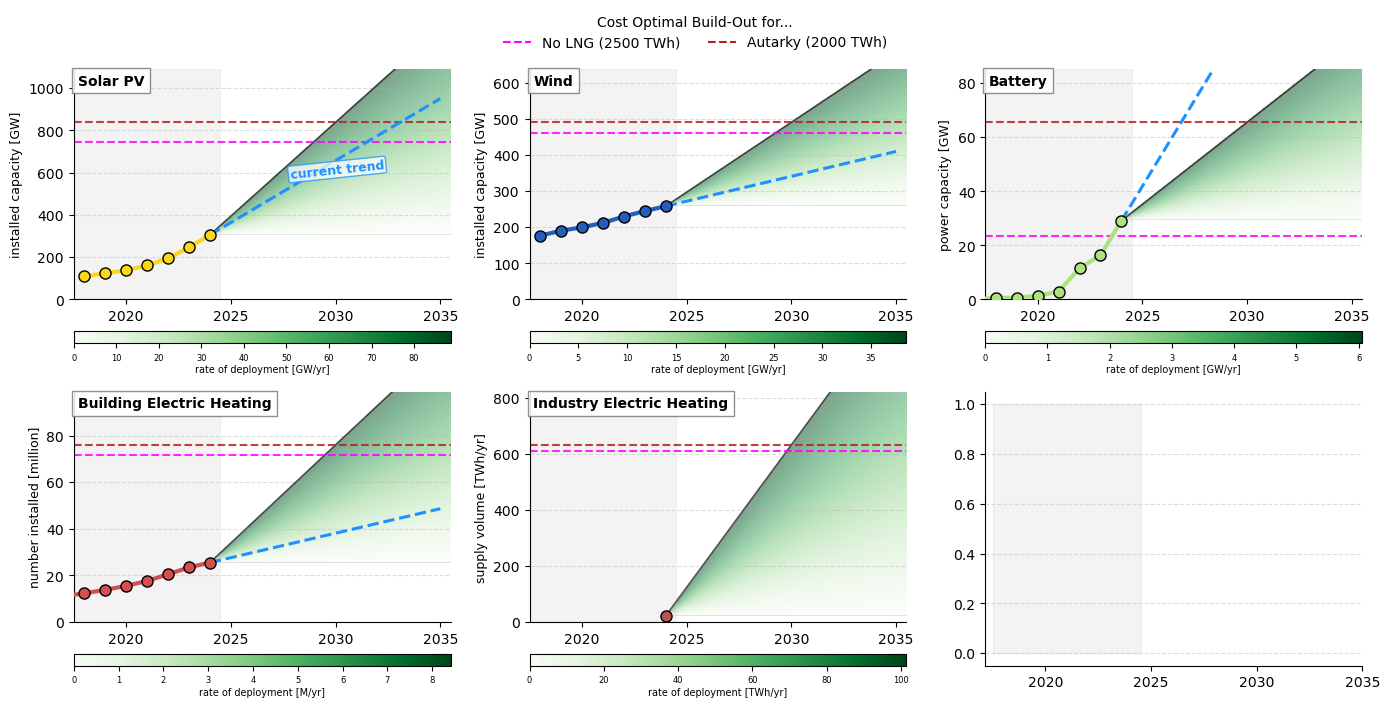

In [95]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colorbar import ColorbarBase
from mpl_toolkits.axes_grid1 import make_axes_locatable


def add_gradient_fill(ax, val_2024, target_2030, target_2035,
                      x_2024=2024, x_deadline=2030, cmap_name='Greens'):
    """
    Fill a region with a colormap encoding the required deployment rate
    (gradient) from (2024, val_2024) to any point (x, y) in the region.

    For each pixel, the color = (y - val_2024) / (x - 2024), i.e. the slope
    of the ray from the 2024 pivot to that point. Iso-color lines are rays
    fanning out from (2024, val_2024).

    Region mask:
      - y >= val_2024  (above the current value)
      - x >= 2024      (future only)
      - y <= val_2024 + slope_diag * (x - 2024)  (below the diagonal
        from (2024, val_2024) to (x_deadline, target_2035))

    grad_slow = 0 (horizontal ray), grad_fast = steepest ray (reach target by x_deadline).
    """
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    x_left, x_right = xlim
    y_bot, y_top = ylim

    # Build a pixel grid in data coordinates
    nx, ny = 600, 400
    x_arr = np.linspace(x_left, x_right, nx)
    y_arr = np.linspace(y_bot, y_top, ny)
    X, Y = np.meshgrid(x_arr, y_arr)

    # Gradient at each pixel: slope from (2024, val_2024) to (x, y)
    dt = X - x_2024
    dy = Y - val_2024
    # Avoid division by zero for x <= 2024
    with np.errstate(divide='ignore', invalid='ignore'):
        G = np.where(dt > 0, dy / dt, np.nan)

    # Diagonal upper bound: line from (2024, val_2024) to (x_deadline, target_2035)
    slope_diag = (target_2035 - val_2024) / (x_deadline - x_2024)
    y_diag = val_2024 + slope_diag * (X - x_2024)

    # Mask: only show where
    #   1) x > 2024
    #   2) y >= val_2024
    #   3) y <= diagonal line (upper bound)
    #   4) gradient >= 0
    mask = (dt > 0.05) & (Y >= val_2024) & (Y <= y_diag) & (G >= 0)
    G_masked = np.where(mask, G, np.nan)

    # Colormap: 0 (flat, easy) -> green,  slope_diag (steepest, hardest) -> red
    grad_slow = 0
    grad_fast = slope_diag
    cmap = plt.get_cmap(cmap_name)
    norm = mcolors.Normalize(vmin=grad_slow, vmax=grad_fast)

    # Draw the gradient contour first (lowest zorder)
    ax.imshow(
        G_masked,
        extent=[x_left, x_right, y_bot, y_top],
        origin='lower',
        aspect='auto',
        cmap=cmap,
        norm=norm,
        alpha=0.5,
        zorder=0,
        interpolation='bilinear',
    )

    # Diagonal boundary line
    x_diag_end = x_2024 + (y_top - val_2024) / slope_diag if slope_diag > 0 else x_right
    x_diag_end = min(x_diag_end, x_right)
    y_diag_end = min(val_2024 + slope_diag * (x_diag_end - x_2024), y_top)
    ax.plot([x_2024, x_diag_end], [val_2024, y_diag_end],
            color='black', lw=1.2, ls='-', alpha=0.6, zorder=1)

    # Horizontal target lines
    ax.axhline(target_2030, color='magenta', lw=1.5, ls='--', alpha=0.85, zorder=1)
    ax.axhline(target_2035, color='firebrick', lw=1.5, ls='--', alpha=0.85, zorder=1)

    return norm, cmap


def add_colorbar_below(fig, ax, norm, cmap, unit='GW/yr'):
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("bottom", size="5%", pad=0.32)
    cb = ColorbarBase(cax, cmap=cmap, norm=norm, orientation='horizontal')
    cb.set_label(f'rate of deployment [{unit}]', fontsize=7, labelpad=2)
    cb.ax.tick_params(labelsize=6)
    return cb

# Thematic y-labels for each subplot, matching units and technology:
ylabel_themes = [
    "installed capacity [GW]",    # Solar PV
    "installed capacity [GW]",   # Onshore Wind
    # "installed capacity [GW]",  # Offshore Wind
    "power capacity [GW]",           # Battery
    "number installed [million]",        # Heat Pumps
    "supply volume [TWh/yr]",    # Industry HPs
]

fig, axs = plt.subplots(2, 3, figsize=(14, 6.5))

# techs = ['Solar PV', 'Onshore Wind', 'Offshore Wind', 'Battery', 'Building Electric Heating', 'Industry Electric Heating']
techs = ['Solar PV', 'Wind', 'Battery', 'Building Electric Heating', 'Industry Electric Heating']
# units = ['GW/yr', 'GW/yr', 'GW/yr', 'GW/yr', 'M/yr', 'TWh/yr']
units = ['GW/yr', 'GW/yr','GW/yr', 'M/yr', 'TWh/yr']
# colors_tech = ['#f9d71c', '#235ebc', '#6895dd', '#ace37f', '#d35050', '#b8544f']
colors_tech = ['#f9d71c', '#235ebc', '#ace37f', '#d35050', '#b8544f']
# val_2024s =    [250, 200,  40,  20,  25,  22]
target_nolng = model_projection_df.loc[idx[:, :, 2030], 'value'].values.tolist()
target_autarky = model_projection_df.loc[idx[:, :, 2035], 'value'].values.tolist()

years_hist = np.arange(2018, 2025)
np.random.seed(42)
norms_cmaps = []

for (i, ax), vals in zip(
    enumerate(axs.flatten()),
    [
        renewables['solar'],
        # renewables['onwind'],
        # renewables['offwind'],
        renewables['wind'],
        bat,
        heat_pumps_europe,
        pd.Series(22, index=[2024]), # add source
    ]
):
    vals.index = vals.index.astype(int)

    y_max = max(target_nolng[i], target_autarky[i]) * 1.3
    ax.set_ylim(0, y_max)
    ax.set_xlim(2017.5, 2035.5)

    # Draw the contour background FIRST!
    norm, cmap = add_gradient_fill(
        ax, vals.loc[2024], target_nolng[i], target_autarky[i],
        x_2024=2024, x_deadline=2030,
    )
    norms_cmaps.append((norm, cmap, units[i]))

    # Draw extrapolation/forecast trend second, so it's over contour but under history
    if i < 5:
        # Calculate linear gradient from 2023 to 2024
        if 2023 in vals.index and 2024 in vals.index:
            y_2023 = vals.loc[2023]
            y_2024 = vals.loc[2024]
            slope_trend = y_2024 - y_2023
            x_extra = np.array([2024, 2035])
            y_extra = y_2024 + slope_trend * (x_extra - 2024)
            # Plot as dashed thick blue line as the MIDDLE zorder (below history)
            extrap_line, = ax.plot(x_extra, y_extra, color='dodgerblue', ls='--', lw=2.2, zorder=3)
            # Only for first subplot, add 'current trend' label above the line
            if i == 0:
                ax.text(
                    2027.8, y_2024 + slope_trend * (2027.8-2024) + 0.03*y_max,
                    'current trend',
                    fontsize=9, fontweight='bold', color='dodgerblue',
                    ha='left', va='bottom', rotation=6, zorder=4,
                    bbox=dict(boxstyle='round,pad=0.15', fc='white', ec='dodgerblue', lw=1, alpha=0.75)
                )

    # Draw historical data LAST so it is on top of everything
    ax.plot(
        vals.index, vals,
        color=colors_tech[i], lw=3, marker='o',
        markeredgecolor='black', markerfacecolor=colors_tech[i],
        markersize=8, markeredgewidth=1, zorder=5#, clip_on=False
    )

    # Place the technology name as a text box in the top left instead of as a title
    ax.text(
        0.01, 0.98, techs[i],
        transform=ax.transAxes,
        fontsize=10,
        fontweight='bold',
        va='top',
        ha='left',
        bbox=dict(facecolor='white', edgecolor='gray', alpha=0.87)
    )
    # Remove the ax title since it's now in the box
    # ax.set_title(techs[i], fontsize=10, fontweight='bold')
    ax.set_ylabel(ylabel_themes[i], fontsize=9)  # Add thematic ylabels here

for ax in axs.flatten():
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.fill_between([2017.5, 2024.5], *ax.get_ylim(),
                    color='lightgrey', alpha=0.25, zorder=0)
    ax.grid(True, axis='y', linestyle='--', alpha=0.4)
    ax.set_axisbelow(True)
    ax.set_xticks([2020, 2025, 2030, 2035])

plt.tight_layout(h_pad=1.8)

for i, ax in enumerate(axs.flatten()[:-1]):
    norm, cmap, unit = norms_cmaps[i]
    add_colorbar_below(fig, ax, norm, cmap, unit)

handles = [
    plt.Line2D([0], [0], color='magenta', lw=1.5, ls='--', label='No LNG (2500 TWh)'),
    plt.Line2D([0], [0], color='firebrick', lw=1.5, ls='--', label='Autarky (2000 TWh)'),
]
fig.legend(handles=handles, loc='upper center', bbox_to_anchor=(0.5, 1.08),
           ncol=2, frameon=False, title='Cost Optimal Build-Out for...')

# plt.savefig('/home/claude/gradient_imshow.png', dpi=150, bbox_inches='tight')

print('was kriege ich hin ohne stranded assets -- Toni fragen')
print('add resistive heating to building heat')

plt.savefig('phaseout_trajectory.pdf', bbox_inches='tight')
plt.show()

In [42]:
cap = n_2030.statistics.installed_capacity()

In [45]:
n_2030.links.loc[n_2030.links.carrier.isin(['battery discharger', 'home battery discharger']), 'p_nom_opt'].sum() / 1e3

75.32720092480936

In [ ]:
idx = pd.IndexSlice
model_projection_df.loc[idx[:, :, :], :]

In [56]:
target_nolng = model_projection_df.loc[idx[:, :, 2030], 'value'].values.tolist()
target_nolng

[814.7332590681617,
 257.7538544054705,
 164.3262869539455,
 33.794969277798955,
 78.32735435961104,
 518.37027366284]

In [59]:
heat_pumps_europe

2012     6.3
2013     7.1
2014     7.9
2015     8.8
2016     9.9
2017    11.0
2018    12.3
2019    13.8
2020    15.5
2021    17.6
2022    20.5
2023    23.4
2024    25.5
Name: heat_pumps_europe, dtype: float64

In [63]:
renewables['solar'].index

Index(['2018', '2019', '2020', '2021', '2022', '2023', '2024'], dtype='object')